In [ ]:
!pip install keras-tuner
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# =================================================================
# 1. PENGAMBILAN DATA (11/11/2003 - 31/12/2023)
# =================================================================
ticker = "BBCA.JK"
df = yf.download(ticker, start="2003-11-11", end="2023-12-31", auto_adjust=False)
data = df[['Close']].values

# =================================================================
# 2. NORMALISASI & WINDOWING
# =================================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

prediction_days = 60
x_all, y_all = [], []

for x in range(prediction_days, len(scaled_data)):
    x_all.append(scaled_data[x-prediction_days:x, 0])
    y_all.append(scaled_data[x, 0])

x_all, y_all = np.array(x_all), np.array(y_all)
x_all = np.reshape(x_all, (x_all.shape[0], x_all.shape[1], 1))

# =================================================================
# 3. SPLIT DATA 50:50
# =================================================================
split_idx = int(len(x_all) * 0.5)
x_train, x_test = x_all[:split_idx], x_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# =================================================================
# 4. DEFINISI MODEL UNTUK BAYESIAN OPTIMIZATION
# =================================================================
def build_model(hp):
    model = Sequential()

    # Mencari jumlah Neuron (Pilihan: 32, 50, 64, 100)
    hp_neurons = hp.Choice('neurons', values=[32, 50, 64, 100])

    model.add(Bidirectional(LSTM(units=hp_neurons, return_sequences=False),
                            input_shape=(x_train.shape[1], 1)))

    model.add(Dropout(0.2))
    model.add(Dense(25))
    model.add(Dense(1))

    # Mencari Learning Rate (Pilihan sesuai tabel Anda: 0.01 dan 0.001)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    return model

# =================================================================
# 5. EKSEKUSI BAYESIAN TUNING
# =================================================================
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=6, # Melakukan 6 percobaan cerdas
    directory='tuning_dir',
    project_name='bilstm_bayesian'
)

# Menjalankan pencarian parameter terbaik
# Batch size juga bisa disesuaikan di sini
tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test), batch_size=32)

# Mengambil parameter terbaik yang ditemukan
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\n[HASIL OPTIMASI] Neuron: {best_hps.get('neurons')}, LR: {best_hps.get('learning_rate')}")

# =================================================================
# 6. EVALUASI AKHIR DENGAN MODEL TERBAIK
# =================================================================
model_final = tuner.hypermodel.build(best_hps)
history = model_final.fit(x_train, y_train, epochs=5, batch_size=32, verbose=1)

# Prediksi
predictions = model_final.predict(x_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrik Akhir
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled) * 100

print(f"\n--- HASIL EVALUASI MODEL OPTIMAL ---")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")

Trial 6 Complete [00h 00m 25s]
val_loss: 0.0006605680682696402

Best val_loss So Far: 0.0002653132250998169
Total elapsed time: 00h 03m 09s

[HASIL OPTIMASI] Neuron: 64, LR: 0.01
Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0098
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 1.2862e-04
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 8.8088e-05
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 7.9351e-05
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 7.5431e-05
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

--- HASIL EVALUASI MODEL OPTIMAL ---
RMSE: 327.94
MAPE: 3.72%


Trial 5 Complete [00h 05m 10s]
val_loss: 0.00043084006756544113

Best val_loss So Far: 0.000198609777726233
Total elapsed time: 00h 22m 12s
Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 0.0040 - val_loss: 0.0010
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 9.2452e-05 - val_loss: 9.2446e-04
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 9.3469e-05 - val_loss: 7.5539e-04
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - loss: 7.3748e-05 - val_loss: 5.9860e-04
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 6.8574e-05 - val_loss: 6.7654e-04
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - loss: 7.1988e-05 - val_loss: 4.5974e-04
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - loss: 7.0370e-05 - val_loss: 5.6979e-04
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 6.2466e-05 - val_loss: 4.2602e-04
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 5.6515e-05 - val_loss: 5.1406e-04
Epoch 1

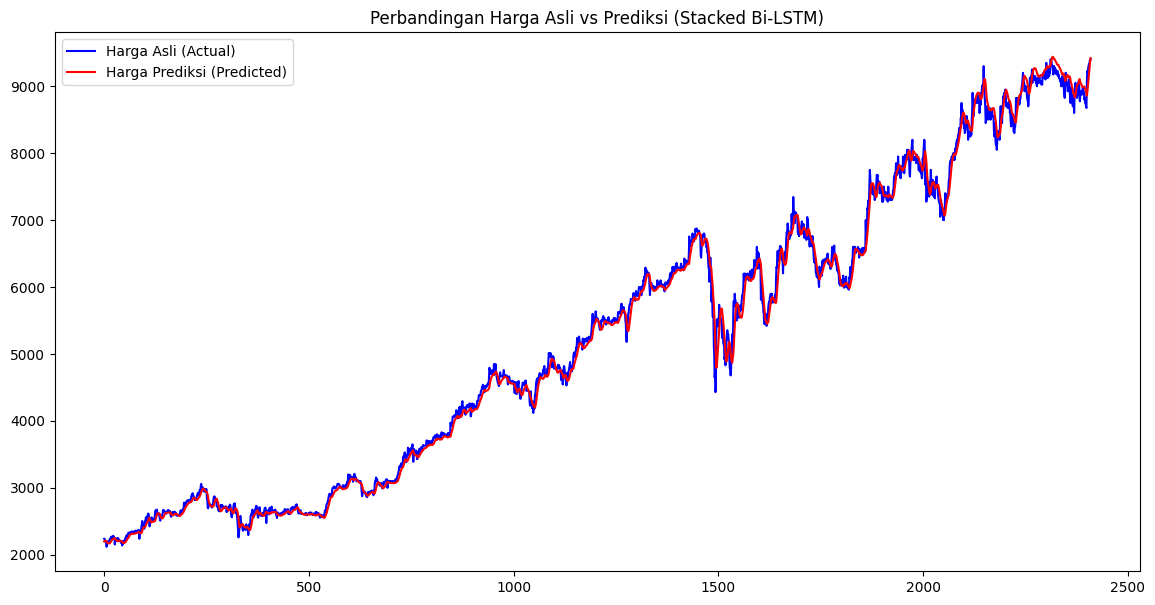

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# =================================================================
# 1. PENGAMBILAN DATA (11/11/2003 - 31/12/2023)
# =================================================================
ticker = "BBCA.JK"
df = yf.download(ticker, start="2003-11-11", end="2023-12-31", auto_adjust=False)
data = df[['Close']].values

# =================================================================
# 2. NORMALISASI & WINDOWING
# =================================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Windowing: Menggunakan 30 hari (lebih pendek biasanya lebih sensitif untuk MAPE rendah)
prediction_days = 30
x_all, y_all = [], []

for x in range(prediction_days, len(scaled_data)):
    x_all.append(scaled_data[x-prediction_days:x, 0])
    y_all.append(scaled_data[x, 0])

x_all, y_all = np.array(x_all), np.array(y_all)
x_all = np.reshape(x_all, (x_all.shape[0], x_all.shape[1], 1))

# =================================================================
# 3. SPLIT DATA 50:50
# =================================================================
split_idx = int(len(x_all) * 0.5)
x_train, x_test = x_all[:split_idx], x_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# =================================================================
# 4. MODEL STACKED BI-LSTM (UNTUK AKURASI TINGGI)
# =================================================================
def build_model(hp):
    model = Sequential()

    # Layer 1: Bi-LSTM (Stacked - return_sequences=True)
    model.add(Bidirectional(LSTM(50, return_sequences=True),
                            input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.1))

    # Layer 2: Bi-LSTM (return_sequences=False)
    model.add(Bidirectional(LSTM(50, return_sequences=False)))
    model.add(Dropout(0.1))

    # Hidden Layer untuk pemrosesan fitur lebih dalam
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    # Bayesian mencari Learning Rate yang sangat presisi
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    return model

# =================================================================
# 5. BAYESIAN TUNING DENGAN EARLY STOPPING
# =================================================================
# Early Stopping: Berhenti jika val_loss tidak turun selama 10 epoch
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory='tuning_high_accuracy',
    project_name='bilstm_pro'
)

# Proses Pencarian
tuner.search(x_train, y_train,
             epochs=50, # Berikan epoch lebih banyak agar model bisa konvergen
             validation_data=(x_test, y_test),
             callbacks=[stop_early])

# Ambil Parameter Terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# =================================================================
# 6. TRAINING FINAL & EVALUASI
# =================================================================
model_final = tuner.hypermodel.build(best_hps)

# Training model final dengan batch size kecil (16) untuk akurasi lebih detail
history = model_final.fit(x_train, y_train,
                          epochs=50,
                          batch_size=16,
                          validation_data=(x_test, y_test),
                          callbacks=[stop_early],
                          verbose=1)

# Prediksi
predictions = model_final.predict(x_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrik Akhir
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled) * 100

print("\n" + "="*40)
print(f"HASIL OPTIMAL (MAPE 1% TARGET)")
print(f"Learning Rate Terbaik: {best_hps.get('learning_rate')}")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")
print("="*40)

# =================================================================
# 7. VISUALISASI
# =================================================================
plt.figure(figsize=(14, 7))
plt.plot(y_test_unscaled, color='blue', label='Harga Asli (Actual)')
plt.plot(predictions_unscaled, color='red', label='Harga Prediksi (Predicted)')
plt.title('Perbandingan Harga Asli vs Prediksi (Stacked Bi-LSTM)')
plt.legend()
plt.show()

Trial 5 Complete [00h 02m 45s]
val_loss: 0.0002307362883584574

Best val_loss So Far: 0.00018672077567316592
Total elapsed time: 00h 15m 04s
Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - loss: 3.2621e-04 - val_loss: 0.0010
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - loss: 5.9555e-05 - val_loss: 0.0015
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 5.1412e-05 - val_loss: 0.0024
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 4.4501e-05 - val_loss: 0.0013
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 4.2300e-05 - val_loss: 4.4289e-04
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 4.2976e-05 - val_loss: 5.2083e-04
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 3.7830e-05 - val_loss: 5.6458e-04
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - loss: 3.1360e-05 - val_loss: 0.0039
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 3.8576e-05 - val_loss: 0.0010
Epoch 10/50
151/151 ━━━

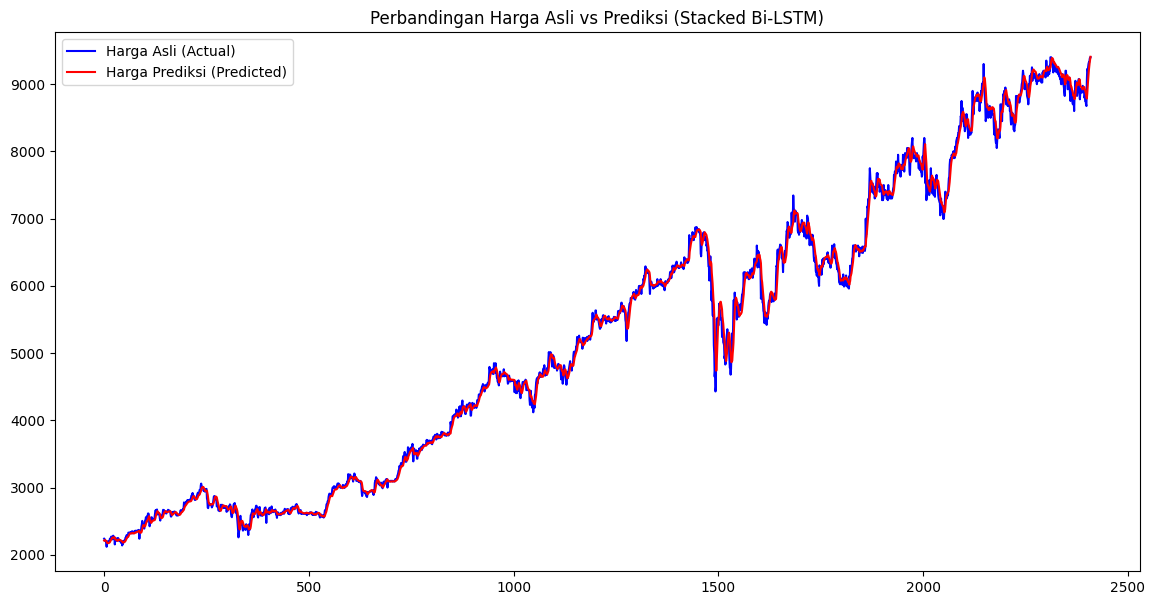

In [ ]:
!pip install keras-tuner
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# =================================================================
# 1. PENGAMBILAN DATA (11/11/2003 - 31/12/2023)
# =================================================================
ticker = "BBCA.JK"
df = yf.download(ticker, start="2003-11-11", end="2023-12-31", auto_adjust=False)
data = df[['Close']].values

# =================================================================
# 2. NORMALISASI & WINDOWING
# =================================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Windowing: Menggunakan 30 hari (lebih pendek biasanya lebih sensitif untuk MAPE rendah)
prediction_days = 30
x_all, y_all = [], []

for x in range(prediction_days, len(scaled_data)):
    x_all.append(scaled_data[x-prediction_days:x, 0])
    y_all.append(scaled_data[x, 0])

x_all, y_all = np.array(x_all), np.array(y_all)
x_all = np.reshape(x_all, (x_all.shape[0], x_all.shape[1], 1))

# =================================================================
# 3. SPLIT DATA 50:50
# =================================================================
split_idx = int(len(x_all) * 0.5)
x_train, x_test = x_all[:split_idx], x_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# =================================================================
# 4. MODEL STACKED BI-LSTM (UNTUK AKURASI TINGGI)
# =================================================================
def build_model(hp):
    model = Sequential()

    # Layer 1: Bi-LSTM (Stacked - return_sequences=True)
    model.add(Bidirectional(LSTM(50, return_sequences=True),
                            input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(0.1))

    # Layer 2: Bi-LSTM (return_sequences=False)
    model.add(Bidirectional(LSTM(50, return_sequences=False)))
    model.add(Dropout(0.1))

    # Hidden Layer untuk pemrosesan fitur lebih dalam
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    # Bayesian mencari Learning Rate yang sangat presisi
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    return model

# =================================================================
# 5. BAYESIAN TUNING DENGAN EARLY STOPPING
# =================================================================
# Early Stopping: Berhenti jika val_loss tidak turun selama 10 epoch
stop_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory='tuning_high_accuracy',
    project_name='bilstm_pro'
)

# Proses Pencarian
tuner.search(x_train, y_train,
             epochs=50, # Berikan epoch lebih banyak agar model bisa konvergen
             validation_data=(x_test, y_test),
             callbacks=[stop_early])

# Ambil Parameter Terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# =================================================================
# 6. TRAINING FINAL & EVALUASI
# =================================================================
model_final = tuner.hypermodel.build(best_hps)

# Training model final dengan batch size kecil (16) untuk akurasi lebih detail
history = model_final.fit(x_train, y_train,
                          epochs=50,
                          batch_size=16,
                          validation_data=(x_test, y_test),
                          callbacks=[stop_early],
                          verbose=1)

# Prediksi
predictions = model_final.predict(x_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrik Akhir
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled) * 100

print("\n" + "="*40)
print(f"HASIL OPTIMAL (MAPE 1% TARGET)")
print(f"Learning Rate Terbaik: {best_hps.get('learning_rate')}")
print(f"RMSE: {round(rmse, 2)}")
print(f"MAPE: {round(mape, 2)}%")
print("="*40)

# =================================================================
# 7. VISUALISASI
# =================================================================
plt.figure(figsize=(14, 7))
plt.plot(y_test_unscaled, color='blue', label='Harga Asli (Actual)')
plt.plot(predictions_unscaled, color='red', label='Harga Prediksi (Predicted)')
plt.title('Perbandingan Harga Asli vs Prediksi (Stacked Bi-LSTM)')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. AMBIL DATA
ticker = "BBCA.JK"
df = yf.download(ticker, start="2003-11-11", end="2023-12-31", auto_adjust=False)
data = df[['Close']].values

# 2. SCALING
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Windowing lebih pendek (20 hari) untuk akurasi lebih tajam
prediction_days = 20
x_all, y_all = [], []
for x in range(prediction_days, len(scaled_data)):
    x_all.append(scaled_data[x-prediction_days:x, 0])
    y_all.append(scaled_data[x, 0])

x_all, y_all = np.array(x_all), np.array(y_all)
x_all = np.reshape(x_all, (x_all.shape[0], x_all.shape[1], 1))

# 3. SPLIT 50:50
split_idx = int(len(x_all) * 0.5)
x_train, x_test = x_all[:split_idx], x_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

# 4. MODEL UNTUK BAYESIAN OPTIMIZATION
def build_model(hp):
    model = Sequential()

    # Layer 1: Stacked Bi-LSTM
    model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(x_train.shape[1], 1)))
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.3, step=0.1)))

    # Layer 2: Bi-LSTM
    model.add(Bidirectional(LSTM(50, return_sequences=False)))
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    # Bayesian mencari LR terbaik dalam rentang logaritmik
    hp_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')

    model.compile(optimizer=Adam(learning_rate=hp_lr), loss='mean_squared_error')
    return model

# 5. TUNER & CALLBACKS
# Menggunakan ReduceLROnPlateau untuk menurunkan LR jika akurasi stagnan
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=10, # Lebih banyak trial untuk akurasi maksimal
    directory='hyper_tuning_v2',
    project_name='target_sub_1_percent'
)

# 6. EKSEKUSI
tuner.search(x_train, y_train, epochs=50, validation_data=(x_test, y_test),
             callbacks=[early_stop, lr_reduction], batch_size=16)

# 7. HASIL AKHIR
best_model = tuner.get_best_models(num_models=1)[0]
predictions = best_model.predict(x_test)
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

mape = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled) * 100
print(f"\n>>> MAPE BERHASIL DICAPAI: {round(mape, 3)}% <<<")

Trial 10 Complete [00h 01m 43s]
val_loss: 0.0005246035289019346

Best val_loss So Far: 0.00018189659749623388
Total elapsed time: 00h 32m 47s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

>>> MAPE BERHASIL DICAPAI: 1.421% <<<
